**Q**: How is a user's response to a treatment defined?

**A**: $$\frac{\delta Y}{\delta T}$$

---

**Q**: In the context of MIMIR, what is the flaw of a model that learns to predict the outcome (attach rate)?

**A**: The model learns to separate users based on their purchasing power rather than their responsiveness to price changes

---

**Q**: Why is it difficult to estimate the slope $\frac{\delta Y_i}{\delta T_i}$ for a single user?

**A**: Because we can never observe the same user under different treatments

---

**Q**: To estimate CATE for a user using linear regression, what should be the general form of the model?

**A**: 

$$
y_i = \beta_0 + \beta_1 t_i + \beta_2 X_i + \beta_3 t_i X_i + e_i,
$$

where $\beta_3$ is a vector coefficient for the features in $X$

---

**Q**: Suppose you want to estimate CATE using a linear model of the form:

$$
y_i = \beta_0 + \beta_1 t_i + \beta_2 X_i + \beta_3 t_i X_i + e_i.
$$

How would you estimate CATE for user $i$ once you've fit the model on the data

**A**: We have:

$$
\hat{\frac{\delta y_i}{\delta t_i}} = \hat{\beta_1} + \hat{\beta_3} X_i
$$

---

**Q**: Suppose you want to estimate CATE using a linear model of the form:

$$
y_i = \beta_0 + \beta_1 t_i + \beta_2 X_i + \beta_3 t_i X_i + e_i.
$$

How would you estimate CATE for user $i$ using the subtraction trick once you've fit the model on the data

**A**: We have:

$$
\hat{\frac{\delta y_i}{\delta t_i}} = \hat{y_i}(t_i + 1) - \hat{y_i}(t_i)
$$

---

**Q**: Suppose you want to estimate CATE using a linear model of the form:

$$
y_i = \beta_0 + \beta_1 t_i + \beta_2 X_i + \beta_3 t_i X_i + e_i.
$$

Explain why the subtraction trick works for estimating CATE

**A**: CATE estimate is given by:

$$
\hat{\frac{\delta y_i}{\delta t_i}} = \hat{\beta}_1 + \hat{\beta}_3 X_i
$$

We have:

$$
\hat{y}_i(t_i) = \hat{\beta}_0 + \hat{\beta}_1 t_i + \hat{\beta}_2 X_i + \hat{\beta}_3 t_i X_i,
$$

and 

$$
\begin{align*}
\hat{y}_i(t_i + 1) 
&= \hat{\beta}_0 + \hat{\beta}_1 ( t_i + 1) + \hat{\beta}_2 X_i + \hat{\beta}_3 (t_i + 1) X_i \\[4pt]
&= \hat{\beta}_0 + \hat{\beta}_1 t_i + \hat{\beta}_1 + \hat{\beta}_2 X_i + \hat{\beta}_3 t_i X_i + \hat{\beta}_3 X_i
\end{align*}
$$

Subtracting them, we get:

$$
\begin{align*}
\hat{y}_i(t_i + 1) - \hat{y}_i(t_i) &=  \hat{\beta}_1 + \hat{\beta}_3 X_i \\[4pt]
&= \hat{\frac{\delta y_i}{\delta t_i}}
\end{align*}
$$

---

**Q**: Explain the process of Effect by Model Quantile evaluation

**A**: 

**Step 1**: Split the data into quantiles based on the model's CATE predictions. <br>
**Step 2**: For each group, compute the average of the CATE predictions and compare it with the estimated ATE for that group. <br>
**Step 3**: A good model should result in monotonicity of the ATE across groups, and within each group, the average CATE prediction should closely match the estimated ATE

---

**Q**: Explain the process of constructing a cumulative effect curve to evaluate a CATE model?

**A**: 

**Step 1**: Sort the data by the model's CATE predictions. <br>
**Step 2**: Estimate the ATE cumulatively for the top 1%, then the top 2%, etc., all the way to 100%. <br>
**Step 3**: Plot these cumulative estimates. A larger area between the curve and the overall ATE line indicates a better model

---

**Q**: What is a major disadvantage of using the area under the Cumulative Effect Curve to compare CATE models?

**A**: The beginning of the curve (e.g., the top 1%) contributes the most to the total area. However, this region has the highest uncertainty because the effect is estimated on a very small sample size.

---

**Q**: How do you construct a cumulative gain curve from a cumulative effect curve?

**A**: By multiplying the estimated ATE at each cumulative step by the cumulative sample proportion ($N_{\text{cum}}/N$)

---

**Q**: What is a disadvantage of a cumulative gain curve?

**A**: It completely ignores calibration

---

**Q**: How is the transformed target variable ($Y_i^*$) defined

**A**: 

$$
Y_i^* = \frac{Y_i - \hat{\mu}_y(X_i)}{T_i - \hat{\mu}_t(X_i)},
$$

where $\mu_y$ is a model for the outcome and $\mu_t$ is a model for the treatment.

---

**Q**: In which scenario is the transformed target variable ($Y_i^*$) too noisy

**A**: When the model for the treatment is too accurate

---

### Deriving the revenue equation and the attach equation in terms of CATE

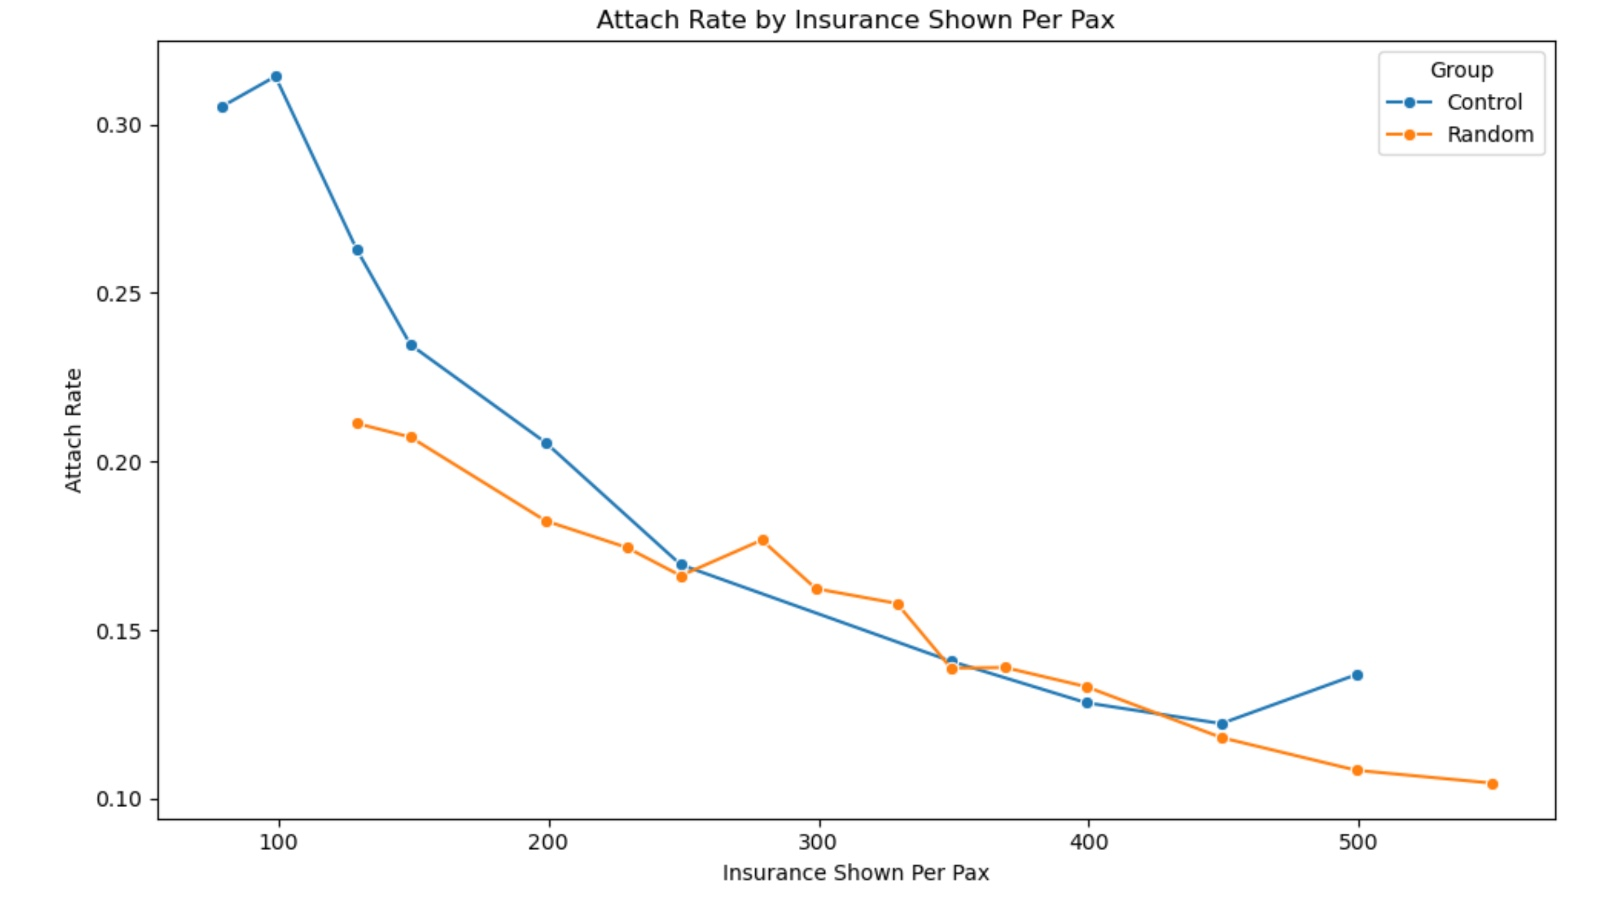

As we can see from the graph of Attach Rate vs Price for random data, there is a linear relationship between attach rate and price shown. So we can write:
$$
\text{attach} \approx \alpha(X) - \tau(X) \cdot \text{price}.
$$
There's an inverse relationship between attach rate and price shown. Hence the negative sign before the second term. $\alpha(X)$ represents the theoretical attach rate of the user if the price shown were zero. Now, the revenue is given by:
$$
\begin{align*}
\text{revenue} 
&= \text{attach} \cdot \text{price} \\[4pt]
&\approx \alpha(X) \cdot \text{price} - \tau(X) \cdot \text{price}^2
\end{align*}
$$
Our objective is usually a convex combination of attach and revenue. So we can write:
$$
\text{objective} = \lambda \cdot \text{revenue} + (1 - \lambda) \cdot \text{attach}
$$
Substituting the formulae, we get:
$$
\begin{align*}
\text{objective} 
&= \lambda \cdot \text{revenue} + (1 - \lambda) \cdot \text{attach} \\[4pt]
&\approx \lambda \cdot \alpha(X) \cdot \text{price} - \lambda  \cdot \tau(X) \cdot \text{price}^2 + (1 - \lambda) \cdot \alpha(X) - (1 - \lambda) \cdot \tau(X) \cdot \text{price}
\end{align*}
$$
To maximize the objective, we take its derivative with respect to price and set it equal to zero:
$$
\frac{d \, \text{objective}}{d \, \text{price}} = \lambda \cdot \alpha(X) - 2 \lambda \cdot \tau(X) \cdot \text{price} - (1 - \lambda) \cdot \tau(X)
$$
So
$$
\frac{d \, \text{objective}}{d \, \text{price}} = 0
$$
implies
$$
\text{price} = \frac{\lambda \cdot \alpha(X) - (1-\lambda) \cdot \tau(X)}{2 \lambda \cdot \tau(X)}
$$